In [1]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("sample_data.csv")

In [3]:
print(df)

   col1 col2  col
0    10    A    5
1    20    B    7
2    20    B    7
3    30    C    8
4  1000    D  500
5    40    E    9
6    50    F   10
7    50    F   10


In [4]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 2


In [6]:
df.drop_duplicates(inplace=True)
print(df.drop_duplicates)

<bound method DataFrame.drop_duplicates of    col1 col2  col
0    10    A    5
1    20    B    7
3    30    C    8
4  1000    D  500
5    40    E    9
6    50    F   10>


In [7]:
df.drop_duplicates(subset=['col1', 'col2'], keep='first', inplace=True)
print(df.drop_duplicates)

<bound method DataFrame.drop_duplicates of    col1 col2  col
0    10    A    5
1    20    B    7
3    30    C    8
4  1000    D  500
5    40    E    9
6    50    F   10>


In [8]:
print("Is 'col' unique?:", df['col'].is_unique)

Is 'col' unique?: True


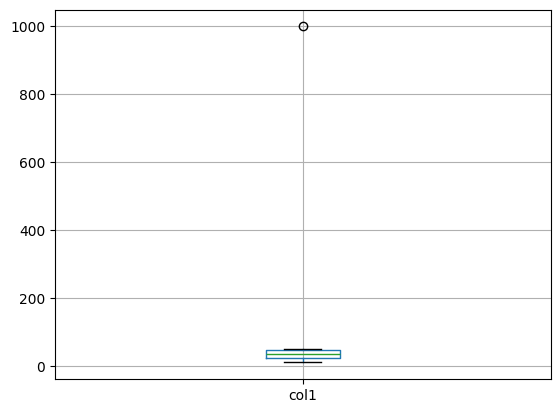

In [9]:
df.boxplot(column=['col1'])
plt.show()

In [10]:
zscore_outliers = df[(np.abs(zscore(df['col'])) > 3)]
print("Z-score Outliers:")
print(zscore_outliers)

Z-score Outliers:
Empty DataFrame
Columns: [col1, col2, col]
Index: []


In [11]:
Q1 = df['col'].quantile(0.25)
Q3 = df['col'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df[(df['col'] < lower_bound) | (df['col'] > upper_bound)]
print("IQR Outliers:")
print(iqr_outliers)

IQR Outliers:
   col1 col2  col
4  1000    D  500


In [13]:
df['col'] = np.log1p(df['col'])
print(df['col'])

0    1.026672
1    1.124748
3    1.162283
4    1.976385
5    1.194706
6    1.223156
Name: col, dtype: float64


In [14]:
df.loc[df['col'] > upper_bound, 'col'] = upper_bound
df.loc[df['col'] < lower_bound, 'col'] = lower_bound

print("Final cleaned dataset:")
print(df.head())

Final cleaned dataset:
   col1 col2  col
0    10    A  3.5
1    20    B  3.5
3    30    C  3.5
4  1000    D  3.5
5    40    E  3.5
